In [1]:
import json
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    plot_alpha_sweep_specific_norm,
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

INFO: P [MainThread] 2025-09-17 15:25:51,119 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_AdaBN_train_performance_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/AdabN/transfer_AdaBN_train_Gauss_a007-a01_CMB_05f_05b_EI_scores.json
Processing: Gauss_Consistency_a007-a01
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


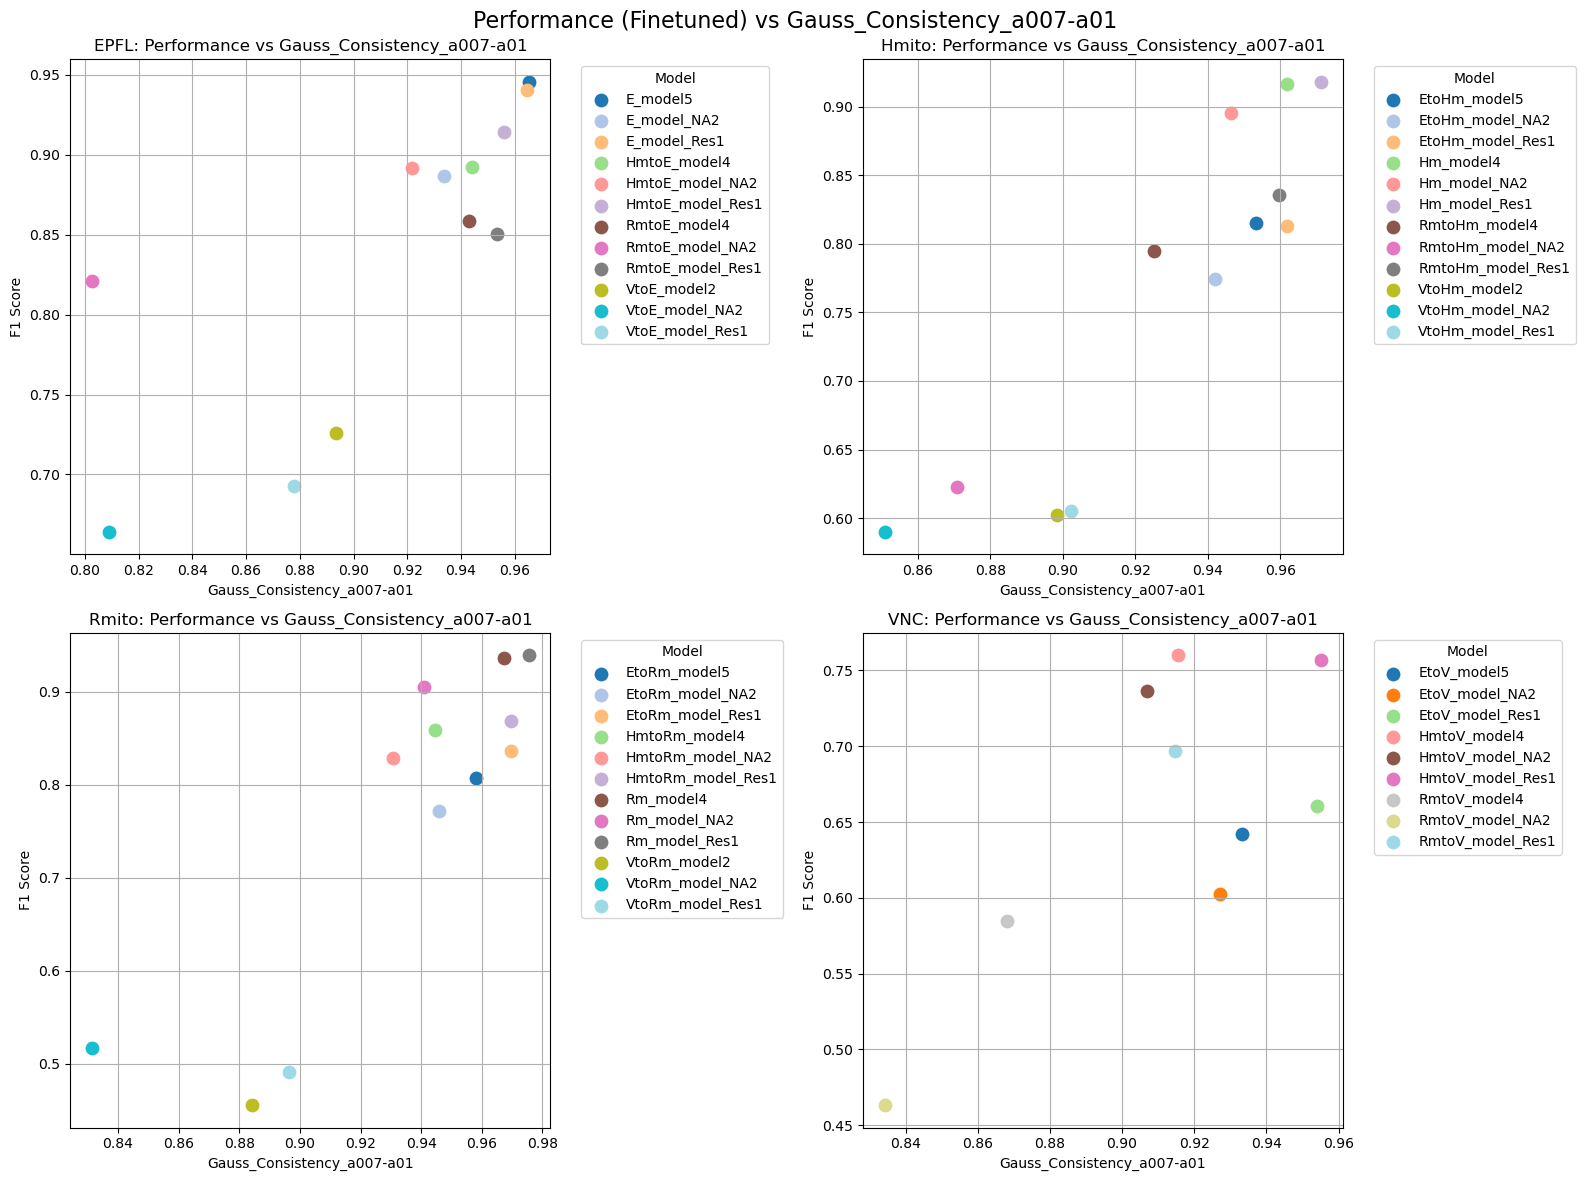

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.76     0.00   0.86        0.00  0.70     0.00
     Hmito    0.91     0.00   0.88        0.00  0.73     0.00
     Rmito    0.87     0.00   0.73        0.01  0.55     0.02
     VNC      0.71     0.03   0.47        0.18  0.39     0.17


In [4]:
base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/AdabN"
#selected_augmentations = ["a001-a003", "a003-a005", "a005-a007", "a007-a01", "a01-a02"]
selected_augmentations = ["a007-a01"]

for aug in selected_augmentations:
    file_name = f"transfer_AdaBN_train_Gauss_{aug}_CMB_05f_05b_EI_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
            transfer_scores=consistency_scores,
            transfer_metric=f"Gauss_Consistency_{aug}",
            finetuned=True
        )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        

# Combined Plot

In [4]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores_with_NORM.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


In [5]:
consistency_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/transfer_GaussSweep_AllLayers_CMB_05f_05b_consistency_scores_with_NORM.json"
with open(consistency_path, "r") as f:
    consistency_scores = json.load(f)["transfer_scores"]

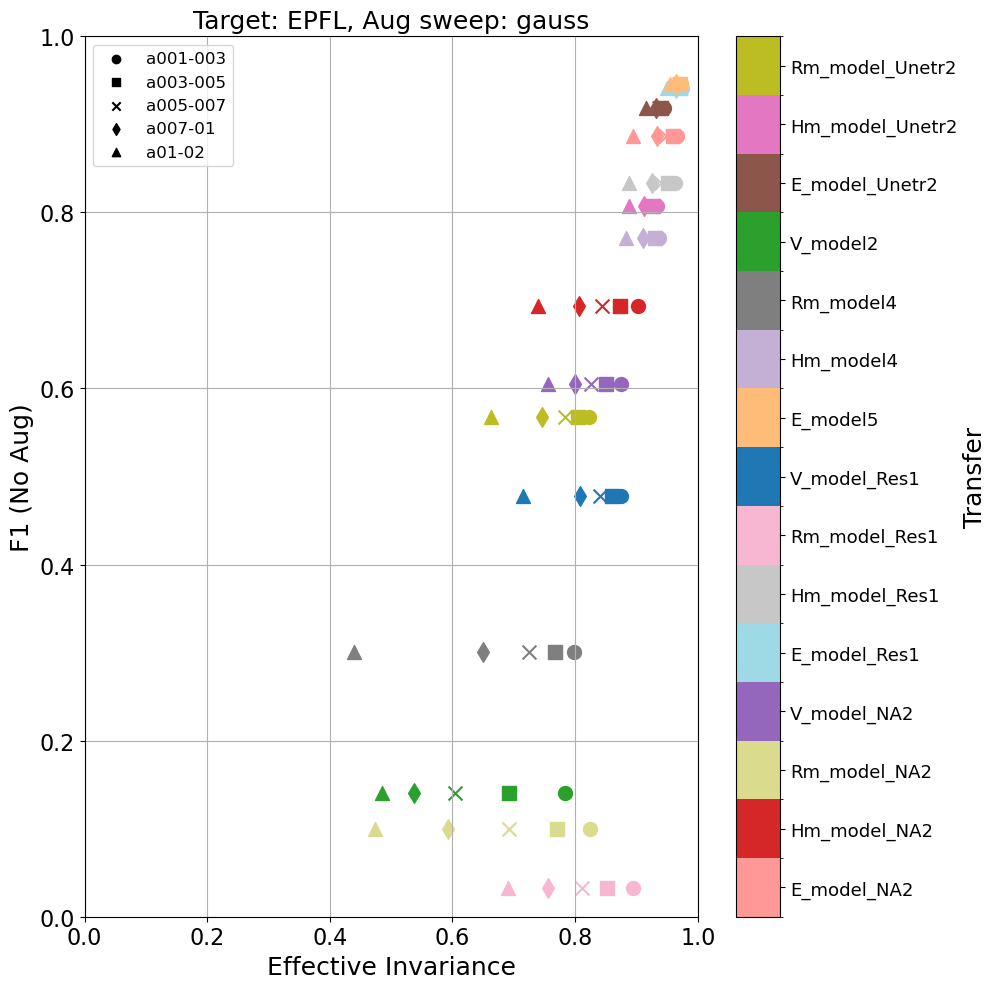

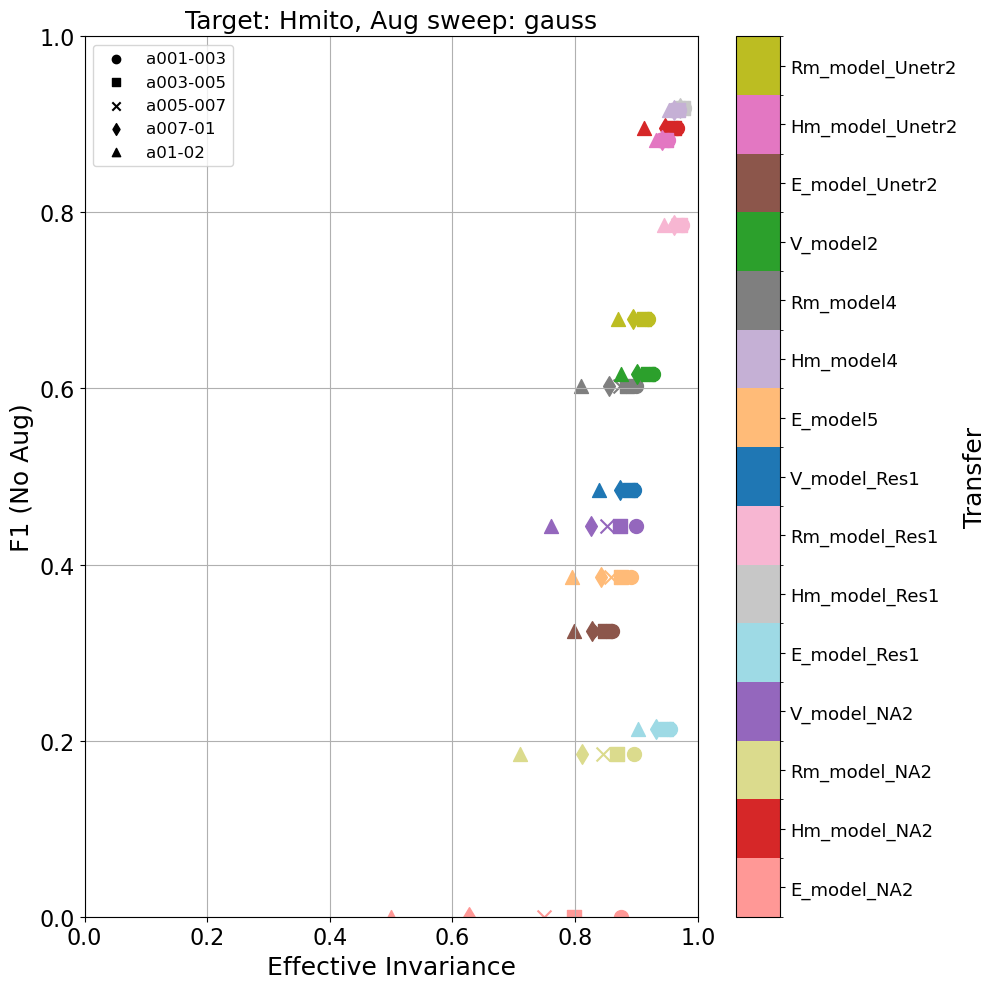

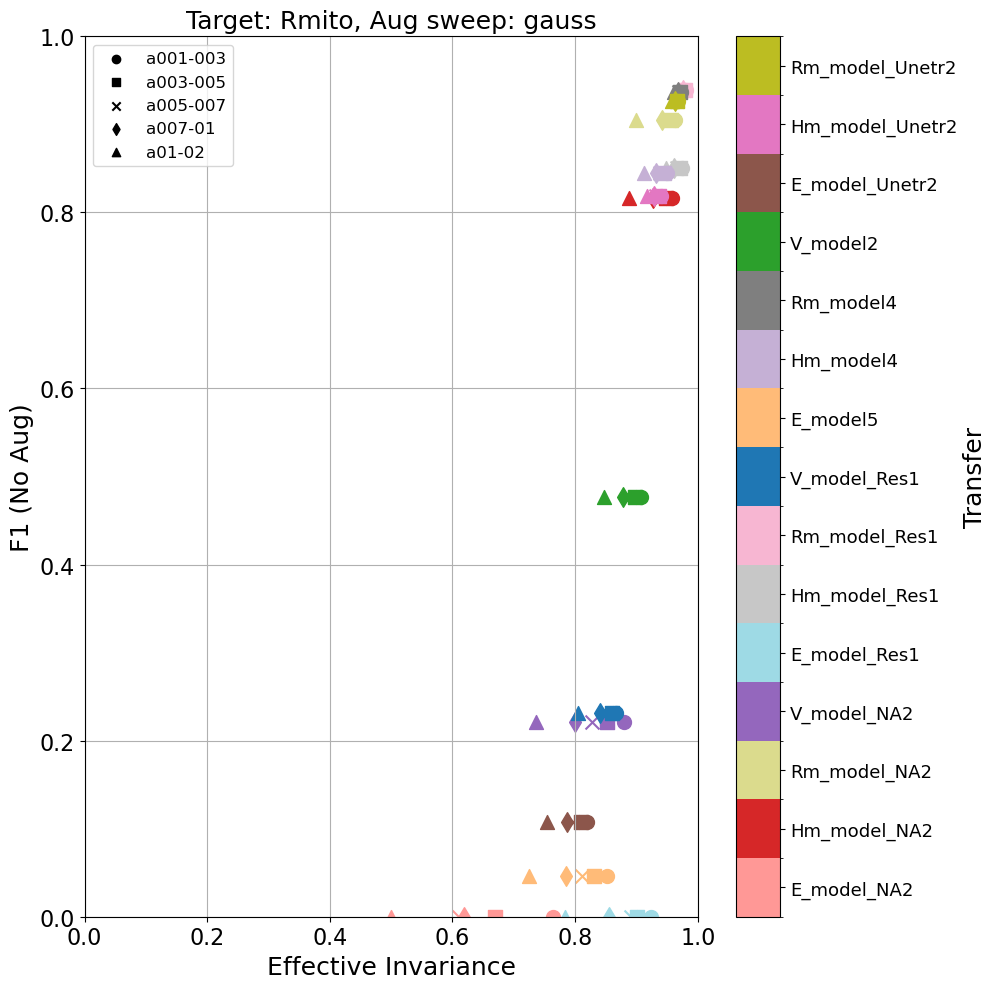

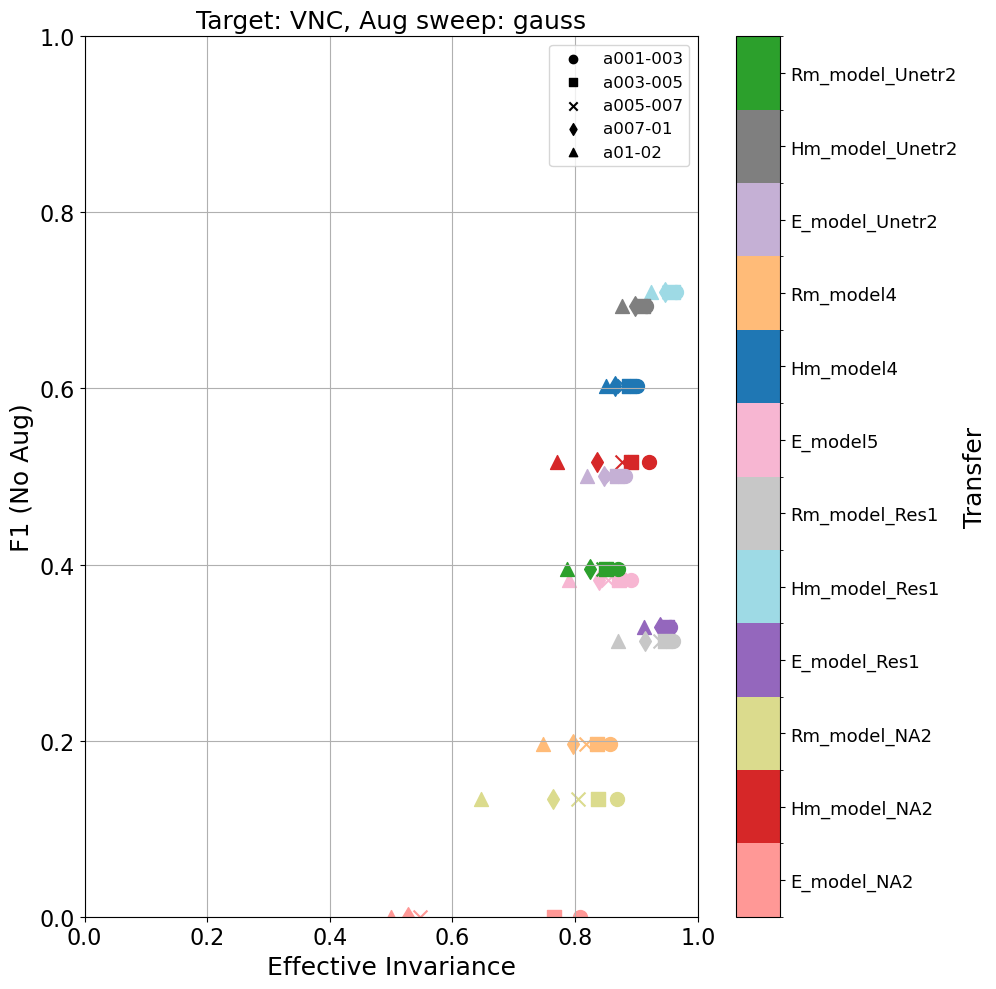

In [ ]:
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-02"],
}
per_target_norms: Dict[str, List[str]] = {
    "EPFL": ["Normalize"],
    "Hmito": ["Normalize"],
    "Rmito": ["Normalize"],
    "VNC": ["Normalize"],
}

for target in consistency_scores.keys():
    plot_alpha_sweep_specific_norm(
        consistency_scores[target],
        performance_scores[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )